# Семинар 1. Инженерные данные и сигналы (Python)

Практическая часть первого модуля. Мы пройдём весь путь от «сырых» файлов до готового набора данных:

1. прочитаем данные из шести разных форматов — CSV, TXT, XLSX, MAT, WAV, PNG;
2. приведём время к машинному виду и посмотрим на временной ряд;
3. посчитаем спектр акустического сигнала и сожмём его до 20 чисел;
4. соберём объединённую таблицу и сохраним её;
5. перепакуем четыре MAT-файла в один файл нужной структуры.

**Что нужно для запуска:** Python 3.9+, `numpy`, `pandas`, `matplotlib`, `scipy`, `openpyxl`, `pillow`.
Установка одной командой: `pip install -r requirements.txt`.

## Импорт библиотек

В Python нет «одной большой среды» — есть набор специализированных библиотек, каждая из которых
отвечает за свой формат или свою математику:

| Задача | Библиотека | Аналог в Julia/MATLAB |
|---|---|---|
| Массивы, векторная арифметика, БПФ | `numpy` | встроенные массивы, `FFTW` |
| Таблицы | `pandas` | `DataFrames` |
| Графики | `matplotlib` | `Plots` |
| MAT-файлы, WAV, фильтры | `scipy` | `MAT`, `WAV`, `DSP` |
| Excel | `openpyxl` (через pandas) | `XLSX` |
| Изображения | `pillow` | `Images` |

Приняты устойчивые сокращения: `np`, `pd`, `plt`. Пишите их так же — так ваш код будет читаться
любым инженером.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.io import loadmat, savemat, wavfile
from PIL import Image
from IPython.display import Audio, display

# Папка с данными семинара и папка для результатов
DATA = Path("data_seminar")
OUT = Path("output")
OUT.mkdir(exist_ok=True)

# Единый стиль графиков на весь ноутбук
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["axes.grid"] = True

print("numpy", np.__version__, "| pandas", pd.__version__)
print("Файлы в папке данных:", len(list(DATA.iterdir())))

numpy 1.26.4 | pandas 2.3.2
Файлы в папке данных: 14


## Чтение CSV-файла с данными энергопотребления

Начнём с самого распространённого формата инженерных данных — CSV. Прочитаем файл с показателями
энергопотребления сталелитейного предприятия. Функция `pd.read_csv` возвращает `DataFrame` —
табличную структуру, где столбцы доступны по именам.

Сразу выведем размерность, чтобы понять масштаб данных: 35 040 строк — это ровно год измерений
с шагом 15 минут (365 × 24 × 4).

In [2]:
df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

print("Размерность данных:", df_energy.shape)
print("Имена столбцов:", list(df_energy.columns))

Размерность данных: (35040, 11)
Имена столбцов: ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


## Первичный осмотр данных

Первое правило инженера при получении данных — посмотреть на них глазами. Выведем первые строки
и типы столбцов. Это помогает сразу обнаружить проблемы: пропуски, некорректные типы,
неожиданные значения.

In [3]:
df_energy.head(10)

,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


`df.info()` — самая быстрая «диагностика» таблицы: типы столбцов, количество непустых значений
и объём занимаемой памяти.

Обратите внимание: столбец `date` имеет тип `object` (то есть строка), а не дату. Для Python это
пока просто текст, с которым нельзя делать арифметику — это мы исправим на следующем шаге.

In [4]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_tCO2_                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

`describe()` даёт сводную статистику по числовым столбцам: среднее, разброс, минимум, максимум
и квартили. Уже на этом этапе видны подозрительные значения — например, нулевые минимумы у
реактивной мощности.

In [5]:
df_energy.describe().T

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive_Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2_tCO2_,35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00


## Преобразование даты и времени

В инженерных данных временные метки часто хранятся как строки. Преобразуем столбец `date` в тип
`datetime64`. Формат `%d/%m/%Y %H:%M` описывает исходную запись `01/01/2018 00:15`.

**Всегда указывайте формат явно.** Без него pandas будет угадывать, и запись `03/04/2018`
может превратиться как в 3 апреля, так и в 4 марта — классический источник молчаливых ошибок.

После преобразования появляется арифметика: разности времён, диапазон, средний шаг измерений.

In [6]:
df_energy["DateTime"] = pd.to_datetime(df_energy["date"], format="%d/%m/%Y %H:%M")

print("Диапазон:", df_energy["DateTime"].min(), "—", df_energy["DateTime"].max())

step = df_energy["DateTime"].diff().dropna()
print("Средний шаг:", round(step.mean().total_seconds(), 2), "сек\n")
print("Встречающиеся шаги:")
print(step.value_counts())

Диапазон: 2018-01-01 00:00:00 — 2018-12-31 23:45:00
Средний шаг: 897.53 сек

Встречающиеся шаги:
DateTime
0 days 00:15:00      34310
-1 days +00:15:00      365
1 days 00:15:00        364
Name: count, dtype: int64


### Первая находка: строки идут не по порядку

Ожидали один шаг 15 минут, а получили три разных, причём один из них **отрицательный**
(`-1 days +00:15` — это минус 23 ч 45 мин). Отрицательный шаг означает, что время в файле
местами идёт назад. Посмотрим на строки вокруг границы суток.

In [7]:
df_energy.iloc[92:98][["date", "NSM", "Usage_kWh", "DateTime"]]

,date,NSM,Usage_kWh,DateTime
92,01/01/2018 23:15,83700,3.53,2018-01-01 23:15:00
93,01/01/2018 23:30,84600,3.24,2018-01-01 23:30:00
94,01/01/2018 23:45,85500,3.67,2018-01-01 23:45:00
95,01/01/2018 00:00,0,3.42,2018-01-01 00:00:00
96,02/01/2018 00:15,900,3.20,2018-01-02 00:15:00
97,02/01/2018 00:30,1800,3.85,2018-01-02 00:30:00


Причина видна сразу: отсчёт **00:00** каждых суток записан не первым, а последним в блоке дня.
Подтверждение — служебный столбец `NSM` (number of seconds from midnight, секунды от полуночи):
у этой строки `NSM = 0`, то есть это действительно начало дня, просто выгрузка расставила строки
в другом порядке.

Это типичная «болезнь» промышленных выгрузок: данные корректны, но порядок строк не соответствует
хронологии. Лечится сортировкой по времени:

```python
df = df.sort_values("DateTime").reset_index(drop=True)
```

⚠️ **Но сортировать прямо сейчас нельзя.** Дальше мы будем присоединять к таблице векторы
температуры и влажности из отдельных файлов, а они выровнены по **порядку строк исходного файла**.
Если отсортировать таблицу до присоединения, температура «уедет» относительно своих строк.
Поэтому: сначала присоединяем внешние данные, сортируем в самом конце. Для графиков же
воспользуемся временной отсортированной копией.

In [8]:
df_time = df_energy.sort_values("DateTime").reset_index(drop=True)

step_sorted = df_time["DateTime"].diff().dropna()
print("После сортировки — уникальные шаги:", step_sorted.unique())
print("Пропусков во времени нет:", (step_sorted == pd.Timedelta("15min")).all())

После сортировки — уникальные шаги: <TimedeltaArray>
['0 days 00:15:00']
Length: 1, dtype: timedelta64[ns]
Пропусков во времени нет: True


## Визуализация временного ряда

График — лучший способ понять поведение системы. Построим график энергопотребления за весь
период. По оси X — время, по Y — киловатт-часы. Видны цикличность (рабочие смены, выходные)
и выбросы.

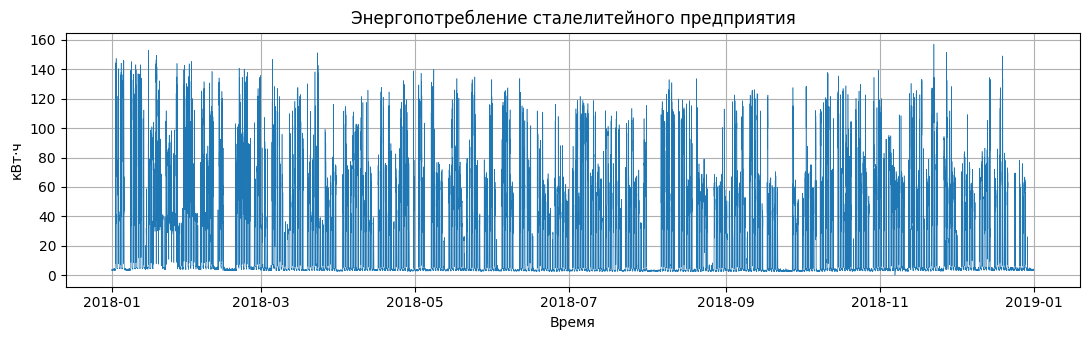

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df_time["DateTime"], df_time["Usage_kWh"], linewidth=0.4)
ax.set_xlabel("Время")
ax.set_ylabel("кВт·ч")
ax.set_title("Энергопотребление сталелитейного предприятия")
plt.tight_layout()
plt.show()

Годовой график слишком плотный — 35 тысяч точек не помещаются в несколько сотен пикселей.
Приблизимся к одной неделе, чтобы увидеть суточную структуру потребления.

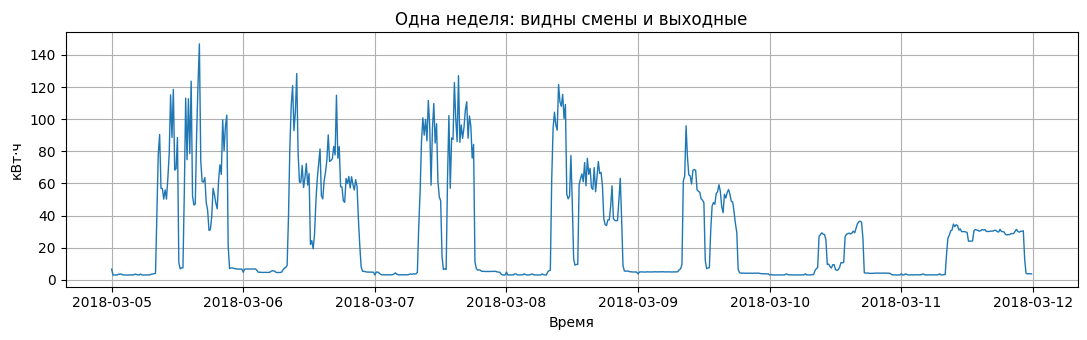

In [10]:
week = df_time[(df_time["DateTime"] >= "2018-03-05") & (df_time["DateTime"] < "2018-03-12")]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(week["DateTime"], week["Usage_kWh"], linewidth=1)
ax.set_xlabel("Время")
ax.set_ylabel("кВт·ч")
ax.set_title("Одна неделя: видны смены и выходные")
plt.tight_layout()
plt.show()

## Чтение данных из MAT-файла

Формат MATLAB (`.mat`) — стандарт в инженерной практике. В нём хранят сигналы, матрицы, структуры.
Прочитаем файл с акустическими сигналами подшипника.

`scipy.io.loadmat` возвращает словарь: ключи — имена переменных, значения — массивы numpy.
Служебные ключи (`__header__`, `__version__`, `__globals__`) отфильтруем.

In [11]:
bearing = loadmat(DATA / "Bearing.mat")

keys = [k for k in bearing if not k.startswith("__")]
print("Ключи в файле:", keys)
print("Размер сигнала normal:", bearing["normal"].shape)

Ключи в файле: ['normal', 'inner', 'roller', 'outer']
Размер сигнала normal: (1, 120000)


## Преобразование MAT-данных в вектор

Данные из MAT-файла хранятся как матрицы размером 1×N — так устроен MATLAB, где скаляров и
векторов «нет», всё является матрицей. Приведём их к одномерным массивам методом `.ravel()`
(аналог `vec` в Julia).

Теперь это обычный массив numpy, с которым можно выполнять математические операции.

In [12]:
normal = bearing["normal"].ravel()
roller = bearing["roller"].ravel()
inner = bearing["inner"].ravel()
outer = bearing["outer"].ravel()

print("Тип данных:", type(normal), normal.dtype)
print("Длина сигнала:", len(normal))
print("Первые 5 отсчётов нормального сигнала:", normal[:5])

Тип данных: <class 'numpy.ndarray'> float64
Длина сигнала: 120000
Первые 5 отсчётов нормального сигнала: [ 0.08866154  0.05862092 -0.056952   -0.05862092 -0.04985908]


Сигнал записан с частотой дискретизации 10 000 Гц, значит 120 000 отсчётов — это 12 секунд записи.
Сравним четыре состояния подшипника «на глаз»: уже без всякой математики видно, что дефекты
дают ударные всплески.

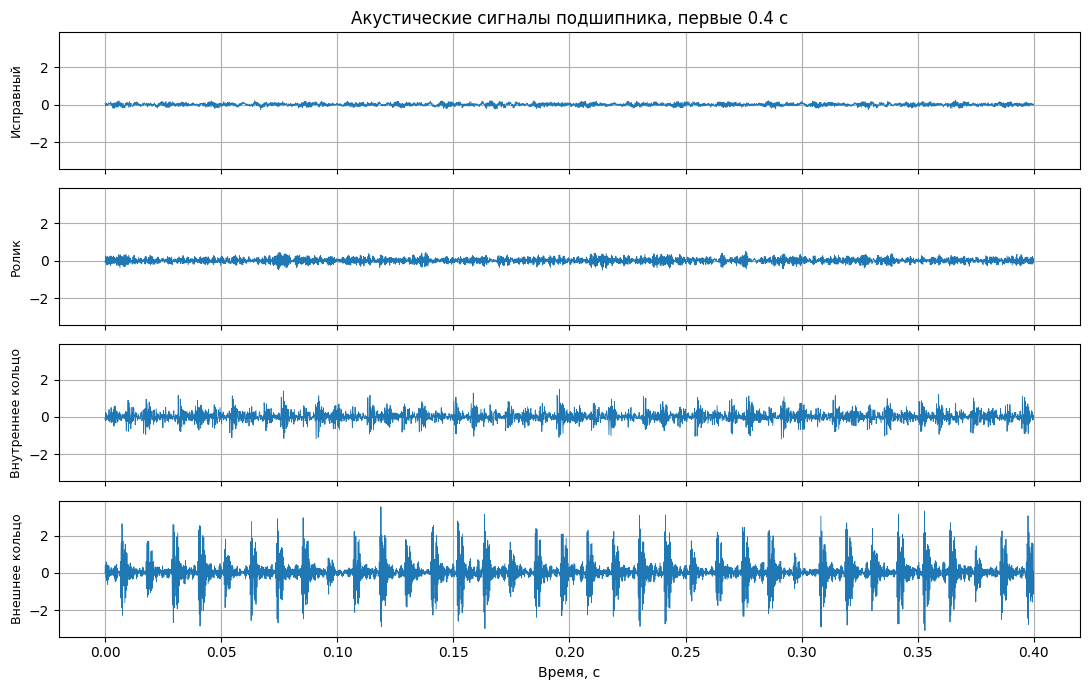

In [54]:
fs = 10_000  # Гц, частота дискретизации стенда
t = np.arange(4000) / fs

fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, (name, sig) in zip(axes, [("Исправный", normal), ("Ролик", roller),
                                 ("Внутреннее кольцо", inner), ("Внешнее кольцо", outer)]):
    ax.plot(t, sig[:4000], linewidth=0.6)
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("Время, с")
axes[0].set_title("Акустические сигналы подшипника, первые 0.4 с")
plt.tight_layout()
plt.show()

## Чтение аудиофайла WAV

Акустические данные часто хранятся в аудиоформатах. Функция `scipy.io.wavfile.read` возвращает
частоту дискретизации и массив отсчётов.

Важная деталь: WAV обычно хранит **целые** числа (`int16`, диапазон −32768…32767). Для расчётов
их нужно нормировать в диапазон −1…1, поделив на 32768 — иначе амплитуды спектра будут
«в попугаях».

In [55]:
fs_wav, wav_signal = wavfile.read(DATA / "Подшипник_1.wav")

print("Частота дискретизации:", fs_wav, "Гц")
print("Тип отсчётов:", wav_signal.dtype, "| количество:", len(wav_signal))
print("Длительность:", round(len(wav_signal) / fs_wav, 2), "сек")

wav_signal = wav_signal.astype(np.float64) / 32768.0  # нормировка int16 -> [-1, 1]
print("Диапазон после нормировки:", wav_signal.min().round(3), "...", wav_signal.max().round(3))

Частота дискретизации: 10000 Гц
Тип отсчётов: int16 | количество: 120000
Длительность: 12.0 сек
Диапазон после нормировки: -0.282 ... 0.311


## Прослушивание аудиофайла

В Jupyter аудио воспроизводится встроенным плеером `IPython.display.Audio` — отдельная библиотека
не нужна. Прослушивание сигнала — недооценённый инструмент диагностики: ухо ловит стук
подшипника раньше, чем это делает статистика.

In [56]:
display(Audio(wav_signal, rate=fs_wav))

## Спектральный анализ через БПФ

Быстрое преобразование Фурье переводит сигнал из временной области в частотную. Это ключевой
инструмент анализа вибраций и акустики.

Порядок действий:

1. **Центрируем** сигнал — вычитаем среднее, чтобы постоянная составляющая не давала пик на 0 Гц.
2. Применяем `np.fft.rfft` — версия БПФ для вещественных сигналов, сразу возвращает только
   положительные частоты (от 0 до частоты Найквиста fs/2).
3. Берём модуль `np.abs` — получаем амплитудный спектр.
4. Ось частот строит `np.fft.rfftfreq(N, 1/fs)`.

Отсчётов во времени: 4000 -> точек спектра: 2001
Разрешение по частоте: 2.5 Гц | частота Найквиста: 5000.0 Гц


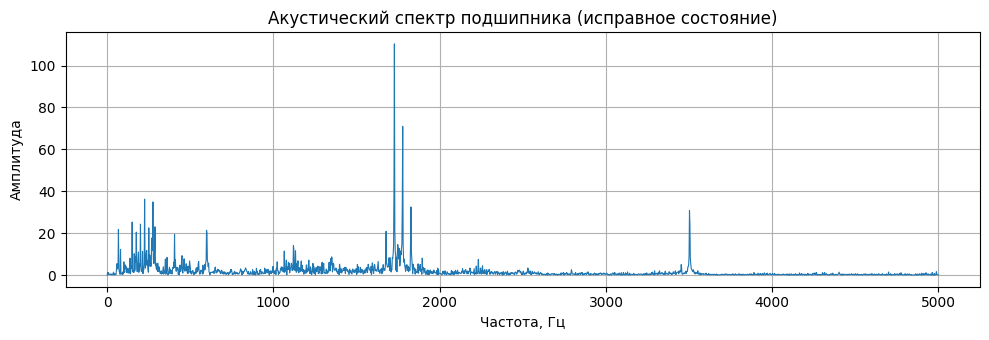

In [57]:
N = 4000
signal = normal[:N] - normal[:N].mean()          # центрирование

spectrum = np.abs(np.fft.rfft(signal))            # амплитудный спектр
freqs = np.fft.rfftfreq(N, d=1 / fs)          # ось частот, Гц

print("Отсчётов во времени:", N, "-> точек спектра:", len(spectrum))
print("Разрешение по частоте:", fs / N, "Гц | частота Найквиста:", fs / 2, "Гц")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(freqs, spectrum, linewidth=0.8)
ax.set_xlabel("Частота, Гц")
ax.set_ylabel("Амплитуда")
ax.set_title("Акустический спектр подшипника (исправное состояние)")
plt.tight_layout()
plt.show()

## Сжатие данных через спектр

Одна из практических задач — сжатие. Посмотрим, в каком диапазоне сосредоточена основная энергия
сигнала. Для этого построим кумулятивную (накопленную) долю энергии: энергия пропорциональна
квадрату амплитуды.

Пересечение с линией 0.95 показывает частоту, ниже которой лежит 95 % энергии сигнала — всё,
что выше, для многих задач можно отбросить.

95 % энергии сосредоточено ниже 2572 Гц


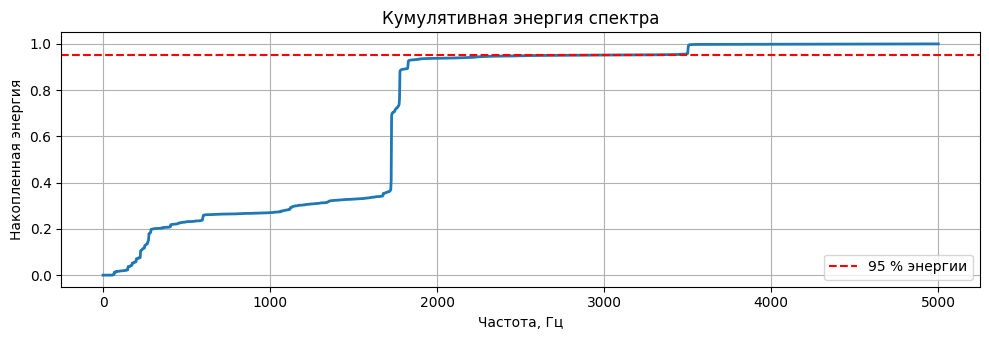

In [58]:
amplitudes = spectrum
cum_energy = np.cumsum(amplitudes ** 2) / np.sum(amplitudes ** 2)

f95 = freqs[np.searchsorted(cum_energy, 0.95)]
print("95 % энергии сосредоточено ниже", round(f95), "Гц")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(freqs, cum_energy, linewidth=2)
ax.axhline(0.95, linestyle="--", color="red", label="95 % энергии")
ax.set_xlabel("Частота, Гц")
ax.set_ylabel("Накопленная энергия")
ax.set_title("Кумулятивная энергия спектра")
ax.legend()
plt.tight_layout()
plt.show()

## Выбор информативных частотных полос

Разобьём диапазон 0…5000 Гц на 20 равных полос и вычислим среднюю амплитуду в каждой. Это даст
компактное представление сигнала — **20 чисел вместо 4000 отсчётов**, которые уже можно положить
строкой в таблицу и подать в модель.

Такие числа называют *признаками* (features), а сам приём — полосовой энергетической
характеристикой спектра.

Сжатие: 4000 отсчётов -> 20 чисел
[4.073 4.607 2.354 1.347 3.166 2.507 5.393 4.943 1.298 1.177 0.743 0.603
 0.455 1.082 1.363 0.366 0.311 0.378 0.302 0.319]


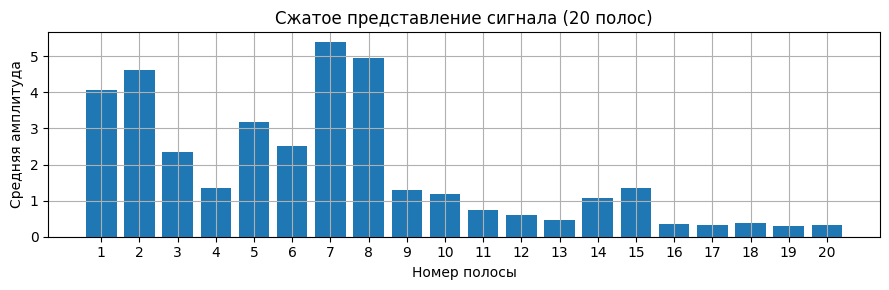

In [59]:
n_bands = 20
band_edges = np.linspace(0, 5000, n_bands + 1)
fft_features = np.zeros(n_bands)

for i in range(n_bands):
    mask = (freqs >= band_edges[i]) & (freqs < band_edges[i + 1])
    if mask.any():
        fft_features[i] = amplitudes[mask].mean()

print("Сжатие:", N, "отсчётов ->", n_bands, "чисел")
print(np.round(fft_features, 3))

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(1, n_bands + 1), fft_features)
ax.set_xlabel("Номер полосы")
ax.set_ylabel("Средняя амплитуда")
ax.set_title("Сжатое представление сигнала (20 полос)")
ax.set_xticks(np.arange(1, n_bands + 1))
plt.tight_layout()
plt.show()

Оформим расчёт признаков как функцию и применим её ко всем четырём состояниям подшипника.
Получится таблица 4 × 20 — заготовка обучающей выборки для будущей модели диагностики.

In [60]:
def band_features(signal, fs=10_000, N=4000, n_bands=20, f_max=5000):
    """Средняя амплитуда спектра в равных частотных полосах."""
    x = signal[:N] - signal[:N].mean()
    amp = np.abs(np.fft.rfft(x))
    freqs = np.fft.rfftfreq(N, d=1 / fs)
    edges = np.linspace(0, f_max, n_bands + 1)
    return np.array([amp[(freqs >= edges[i]) & (freqs < edges[i + 1])].mean() for i in range(n_bands)])


states = {"normal": normal, "roller": roller, "inner": inner, "outer": outer}
features_table = pd.DataFrame(
    {name: band_features(sig) for name, sig in states.items()},
    index=[f"полоса_{i+1}" for i in range(20)],
).T

features_table.round(3)

,полоса_1,полоса_2,полоса_3,полоса_4,полоса_5,полоса_6,полоса_7,полоса_8,полоса_9,полоса_10,полоса_11,полоса_12,полоса_13,полоса_14,полоса_15,полоса_16,полоса_17,полоса_18,полоса_19,полоса_20
normal,4.073,4.607,2.354,1.347,3.166,2.507,5.393,4.943,1.298,1.177,0.743,0.603,0.455,1.082,1.363,0.366,0.311,0.378,0.302,0.319
roller,1.569,4.691,4.047,2.543,1.920,1.316,1.843,1.785,6.692,12.395,15.825,19.192,2.612,1.450,1.457,0.963,0.402,0.659,0.211,0.131
inner,1.647,5.790,8.533,9.094,11.505,5.414,7.037,6.859,22.037,22.133,10.735,28.960,23.061,6.210,3.983,3.693,2.716,2.408,0.642,0.165
outer,1.785,5.645,6.537,3.757,4.507,3.425,3.117,3.897,25.224,49.836,44.678,108.854,32.630,7.672,5.728,3.091,5.104,11.105,2.149,0.785


## Чтение изображения

Изображение для компьютера — это тоже массив чисел. Откроем PNG библиотекой `pillow` и посмотрим
его свойства: размер в пикселях и цветовую модель (`RGBA` — красный, зелёный, синий и альфа-канал
прозрачности).

Тип объекта: <class 'PIL.PngImagePlugin.PngImageFile'>
Размер (ширина × высота): (923, 954)
Цветовая модель: RGBA


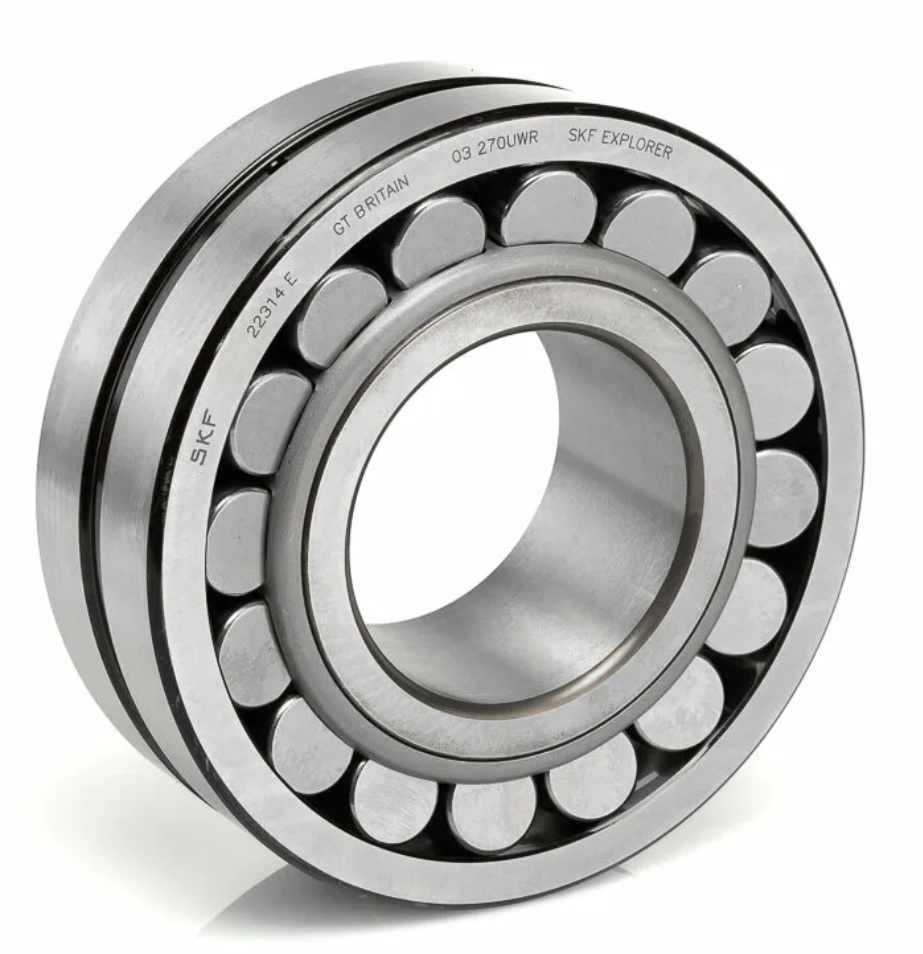

In [61]:
img = Image.open(DATA / "image.png")

print("Тип объекта:", type(img))
print("Размер (ширина × высота):", img.size)
print("Цветовая модель:", img.mode)

img

## Преобразование изображения в числовую матрицу

`np.asarray` превращает картинку в трёхмерный массив. Первые два измерения — строки и столбцы
пикселей, третье — цветовые каналы.

Исходные значения целые, 0…255 (один байт на канал). Поделив на 255, получаем привычный
инженерный диапазон 0…1, где 0 — отсутствие цвета, 1 — максимальная интенсивность,
а для альфа-канала 1 означает полную непрозрачность.

In [62]:
channels = np.asarray(img, dtype=np.float64) / 255.0

print("Форма массива:", channels.shape, "(строки, столбцы, каналы)")
print("Диапазон значений:", channels.min(), "...", channels.max())
print("\nЛевый верхний пиксель (R, G, B, A):", channels[0, 0])

Форма массива: (954, 923, 4) (строки, столбцы, каналы)
Диапазон значений: 0.0 ... 1.0

Левый верхний пиксель (R, G, B, A): [0.99607843 0.99607843 0.99607843 1.        ]


Разложим изображение на отдельные каналы. Каждый канал — обычная матрица чисел, к которой
применимы любые операции numpy: фильтрация, пороговая обработка, статистика.

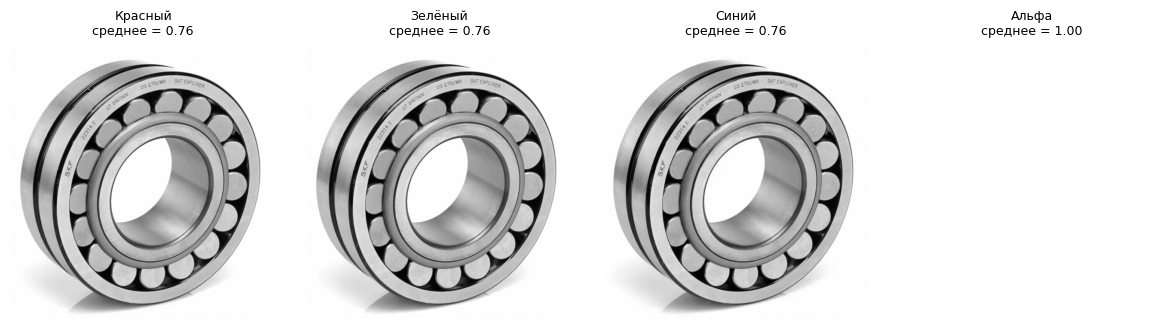

In [63]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, i, name in zip(axes, range(4), ["Красный", "Зелёный", "Синий", "Альфа"]):
    ax.imshow(channels[:, :, i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name}\nсреднее = {channels[:, :, i].mean():.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Чтение текстового файла с данными

Текстовые файлы — простейший формат хранения. Прочитаем txt-файл с числовыми данными о
температуре окружающей среды функцией `np.loadtxt`, определим количество значений, диапазон
и выведем первые 5 значений.

In [64]:
temperature = np.loadtxt(DATA / "температура.txt")
print("Количество значений:", len(temperature))
print("Диапазон:", temperature.min(), "...", temperature.max(), "°C")
print("Первые 5 значений:", temperature[:5])

Количество значений: 35040
Диапазон: -28.9 ... 37.4 °C
Первые 5 значений: [-12.3  -9.8  -9.7 -10.9 -13.4]


## Чтение данных из Excel

Excel-файлы широко распространены в промышленности. Прочитаем xlsx-файл с данными о влажности
функцией `pd.read_excel` (под капотом работает `openpyxl`).

По умолчанию первая строка считается заголовком — как раз наш случай, в ячейке A1 записано имя
столбца `Humidity_Pct`. Метод `.to_numpy()` превращает столбец таблицы в массив numpy.

In [65]:
df_humidity = pd.read_excel(DATA / "влажность.xlsx")
print("Столбцы файла:", list(df_humidity.columns))

humidity = df_humidity["Humidity_Pct"].to_numpy()

print("Количество значений:", len(humidity))
print("Диапазон:", humidity.min(), "...", humidity.max(), "%")
print("Первые 5 значений:", humidity[:5])

Столбцы файла: ['Humidity_Pct']
Количество значений: 35040
Диапазон: 32.8 ... 98.0 %
Первые 5 значений: [91.2 82.8 86.  88.8 86.5]


## Преобразование набора данных

Соберём финальную таблицу. Часть исходных столбцов не нужна, зато нужно добавить данные из
внешних источников. Удалим `NSM`, `WeekStatus`, `Day_of_week`, `Load_Type`, а затем добавим
температуру и влажность, загруженные ранее.

Метод `drop(columns=[...])` возвращает **новую** таблицу и не меняет исходную — это осознанное
решение авторов pandas: так проще откатиться и труднее испортить данные случайно.

In [66]:
df_energy = df_energy.drop(columns=["NSM", "WeekStatus", "Day_of_week", "Load_Type"])
print("Столбцы после удаления:\n", list(df_energy.columns))

Столбцы после удаления:
 ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'DateTime']


Добавим ранее загруженные переменные как новые столбцы. Количество строк обязано совпадать —
проверим это явно перед присваиванием. Такая проверка стоит одну строку и экономит часы отладки.

In [67]:
assert len(temperature) == len(df_energy), "Длина вектора температуры не совпадает с таблицей!"
assert len(humidity) == len(df_energy), "Длина вектора влажности не совпадает с таблицей!"

df_energy["Temperature_C"] = temperature
df_energy["Humidity_Pct"] = humidity

df_energy.head(10)

,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,DateTime,Temperature_C,Humidity_Pct
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,2018-01-01 00:15:00,-12.3,91.2
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,2018-01-01 00:30:00,-9.8,82.8
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2018-01-01 00:45:00,-9.7,86.0
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,2018-01-01 01:00:00,-10.9,88.8
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,2018-01-01 01:15:00,-13.4,86.5
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,2018-01-01 01:30:00,-12.5,89.4
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,2018-01-01 01:45:00,-14.0,85.1
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,2018-01-01 02:00:00,-10.0,82.5
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,2018-01-01 02:15:00,-11.4,89.5
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,2018-01-01 02:30:00,-10.3,92.6


Внешние столбцы присоединены — теперь можно навести порядок во времени, ради которого мы
откладывали сортировку. После неё индекс строк перенумеровываем заново (`reset_index`), иначе
в таблице останутся «дырявые» номера из старого порядка.

In [69]:
df_energy = df_energy.sort_values("DateTime").reset_index(drop=True)

print("Монотонность времени:", df_energy["DateTime"].is_monotonic_increasing)
df_energy.head(3)

Монотонность времени: True


,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,DateTime,Temperature_C,Humidity_Pct
0,01/01/2018 00:00,3.42,3.46,0.0,0.0,70.30,100.0,2018-01-01 00:00:00,-13.7,83.8
1,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,2018-01-01 00:15:00,-12.3,91.2
2,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,2018-01-01 00:30:00,-9.8,82.8


Сохраним преобразованный набор данных в новый CSV-файл. Исходный `Steel_Industry.csv` остаётся
без изменений — все преобразования сохранены в новом файле в папке `output`.

`index=False` не даёт pandas записать в файл служебный столбец с номерами строк.

In [70]:
csv_path = OUT / "Сталелитейные_данные.csv"
df_energy.to_csv(csv_path, index=False, encoding="utf-8")

print("Записано:", csv_path, "|", csv_path.stat().st_size // 1024, "КБ")
pd.read_csv(csv_path, nrows=3)

Записано: output/Сталелитейные_данные.csv | 2675 КБ


,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,DateTime,Temperature_C,Humidity_Pct
0,01/01/2018 00:00,3.42,3.46,0.0,0.0,70.30,100.0,2018-01-01 00:00:00,-13.7,83.8
1,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,2018-01-01 00:15:00,-12.3,91.2
2,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,2018-01-01 00:30:00,-9.8,82.8


## Преобразование MAT-файла

Структура данных в MAT-файле может быть разной. Предположим, нам поступило 4 файла с испытательного
стенда:

* `H_1_0.mat` — полностью исправный подшипник;
* `B_11_1.mat` — неисправность роликового элемента;
* `I_1_1.mat` — неисправность внутреннего кольца;
* `O_6_1.mat` — неисправность внешнего кольца.

Но модель анализа данных ждёт другую структуру — **один** MAT-файл с четырьмя ключами:
`normal`, `roller`, `inner`, `outer`. Приведём данные к этому виду.

Загрузим первый файл и посмотрим, что внутри.

In [35]:
normal_raw = loadmat(DATA / "H_1_0.mat")

print("Ключи:", [k for k in normal_raw if not k.startswith("__")])
print("Форма матрицы:", normal_raw["H_1_0"].shape)

Ключи: ['H_1_0']
Форма матрицы: (420000, 4)


Файл содержит один ключ `H_1_0`, а в нём — матрица 420000×4. Нам известно, что акустические данные
лежат во **втором столбце**, остальные не нужны.

In [30]:
normal_raw = normal_raw["H_1_0"][:, 1]

print("Длина вектора:", len(normal_raw))
print("Первые 5 отсчётов:", normal_raw[:5])

Длина вектора: 420000
Первые 5 отсчётов: [0.078973 0.078973 0.078973 0.079631 0.078973]


Откроем остальные MAT-файлы и извлечём второй столбец из каждого. Вместо копирования одного и
того же кода четыре раза напишем цикл по словарю «имя файла → имя ключа»: так короче и
не получится опечататься в одном из четырёх мест.

In [31]:
files = {
    "normal": ("H_1_0.mat", "H_1_0"),
    "roller": ("B_11_1.mat", "B_11_1"),
    "inner":  ("I_1_1.mat", "I_1_1"),
    "outer":  ("O_6_1.mat", "O_6_1"),
}

data = {}
for label, (file_name, key) in files.items():
    matrix = loadmat(DATA / file_name)[key]
    data[label] = matrix[:, 1]
    print(f"{file_name}: {matrix.shape} -> {data[label].shape} (ключ '{label}')")

H_1_0.mat: (420000, 4) -> (420000,) (ключ 'normal')
B_11_1.mat: (420000, 4) -> (420000,) (ключ 'roller')
I_1_1.mat: (420000, 4) -> (420000,) (ключ 'inner')
O_6_1.mat: (420000, 4) -> (420000,) (ключ 'outer')


Теперь у нас есть словарь с четырьмя векторами акустических данных и правильными ключами.
Сохраним его в новый MAT-файл функцией `savemat`.

In [32]:
mat_path = OUT / "Подшипник_тест.mat"
savemat(mat_path, data)

print("Записано:", mat_path, "|", mat_path.stat().st_size // 1024**2, "МБ")

Записано: output/Подшипник_тест.mat | 12 МБ


Прочитаем созданный файл и убедимся, что структура соответствует требуемой.

In [33]:
reloaded = loadmat(mat_path)

for k in ["normal", "roller", "inner", "outer"]:
    print(f"{k:8s} -> форма {reloaded[k].shape}, первые 3 значения {reloaded[k].ravel()[:3]}")

normal   -> форма (1, 420000), первые 3 значения [0.078973 0.078973 0.078973]
roller   -> форма (1, 420000), первые 3 значения [0.029329 0.025055 0.023739]
inner    -> форма (1, 420000), первые 3 значения [0.07437  0.083576 0.088179]
outer    -> форма (1, 420000), первые 3 значения [0.047082 0.038534 0.033274]


Обратите внимание: после записи и чтения векторы снова стали матрицами 1×420000 — таково
соглашение формата MAT. При дальнейшей работе их опять нужно будет привести к одномерному виду
методом `.ravel()`.